In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("telecom_customer_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

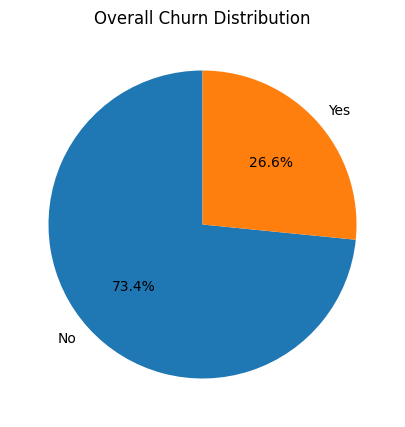

In [6]:
plt.figure(figsize=(7,5))

df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%.1f%%',
    startangle=90
)

plt.title('Overall Churn Distribution')
plt.ylabel('')
plt.show()

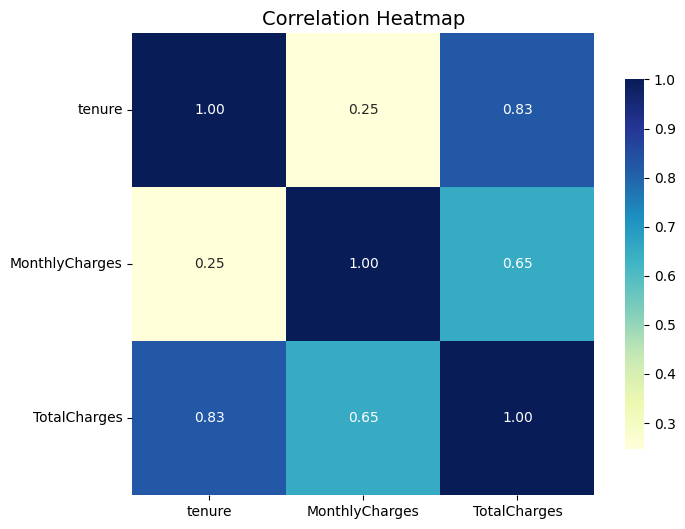

In [7]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',    # Different color theme
    square=True,      # Perfect square boxes
    cbar_kws={'shrink': .8}
)

plt.title('Correlation Heatmap', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


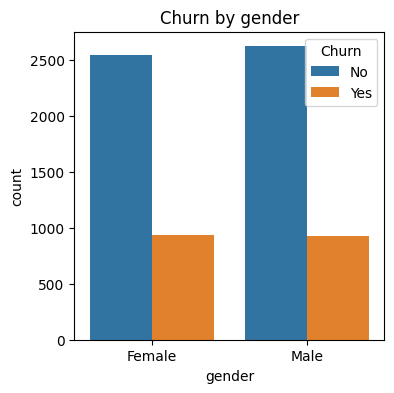

In [10]:
plt.figure(figsize=(4,4))
sns.countplot(x='gender', data = df, hue = 'Churn')
plt.title('Churn by gender')
plt.show()

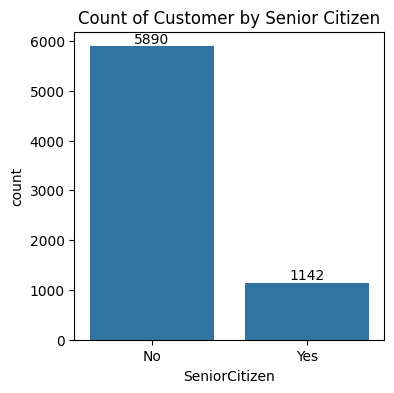

In [11]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x='SeniorCitizen', data = df)
ax.bar_label(ax.containers[0])
plt.title('Count of Customer by Senior Citizen')
plt.show()

In [12]:
ct_pct = pd.crosstab(
    df['SeniorCitizen'], 
    df['Churn'], 
    normalize='index'
) * 100

print(ct_pct)

Churn                 No        Yes
SeniorCitizen                      
No             76.349745  23.650255
Yes            58.318739  41.681261


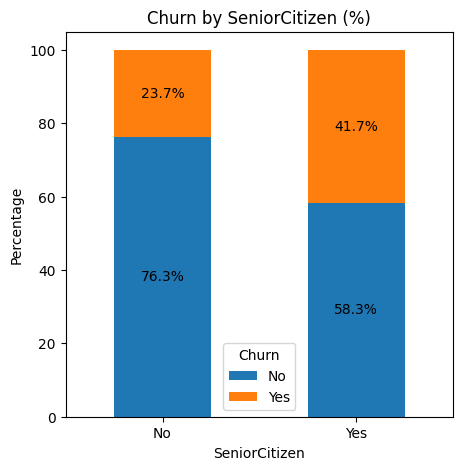

In [13]:
ax = ct_pct.plot(kind='bar', stacked=True, figsize=(5,5))

plt.title('Churn by SeniorCitizen (%)')
plt.ylabel('Percentage')
plt.xlabel('SeniorCitizen')
plt.legend(title="Churn")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.show()

#A higher percentage of senior citizen customers have churned compared to non-senior customers.

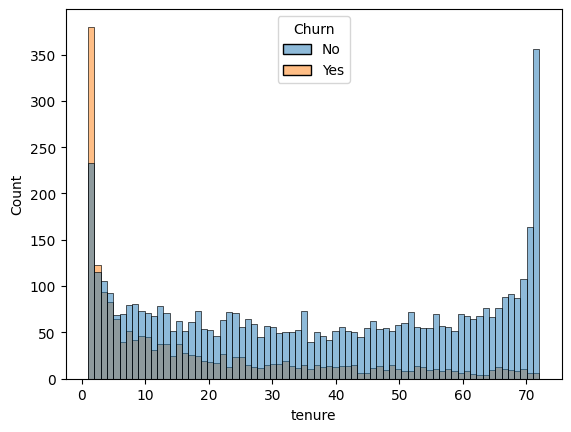

In [14]:
sns.histplot(x='tenure', data = df, bins=72, hue = 'Churn')
plt.show()

#Customers who have used the service for only 1-2 months are more likely to churn.

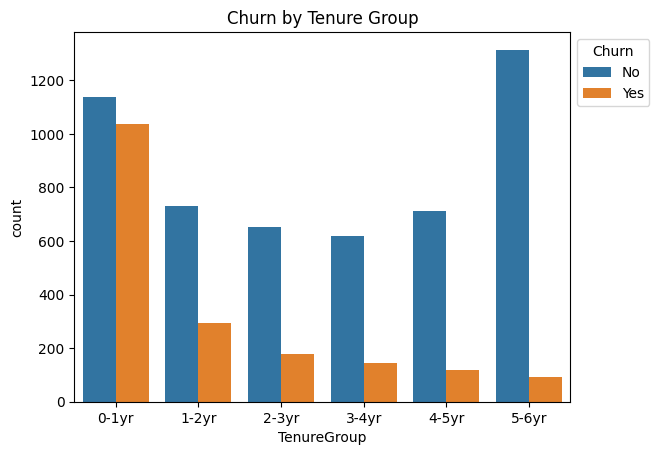

In [15]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr', '5-6yr']

df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels)

sns.countplot(x='TenureGroup', hue='Churn', data=df, palette=['#1f77b4', '#ff7f0e'])
plt.xticks(rotation=0)
plt.title('Churn by Tenure Group')
plt.legend(title='Churn', bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.show()

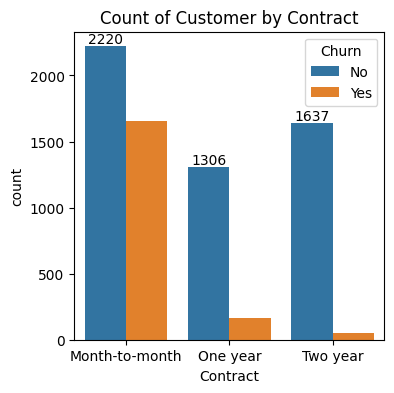

In [16]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x='Contract', data = df, hue='Churn',palette=['#1f77b4', '#ff7f0e'])

ax.bar_label(ax.containers[0])
plt.title('Count of Customer by Contract')
plt.show()

#Customers with month-to-month contracts are more likely to churn compared to those with 1-year or 2-year contracts.

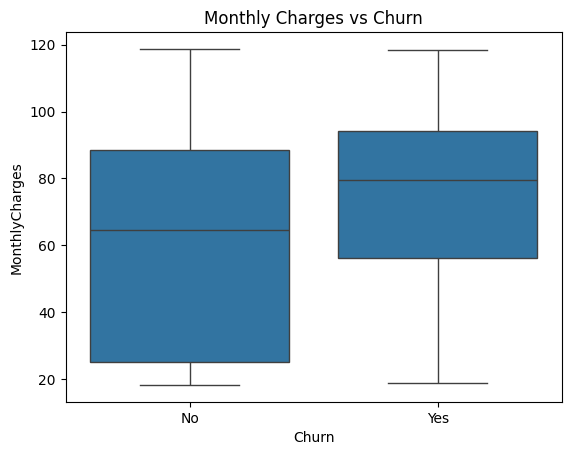

In [17]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

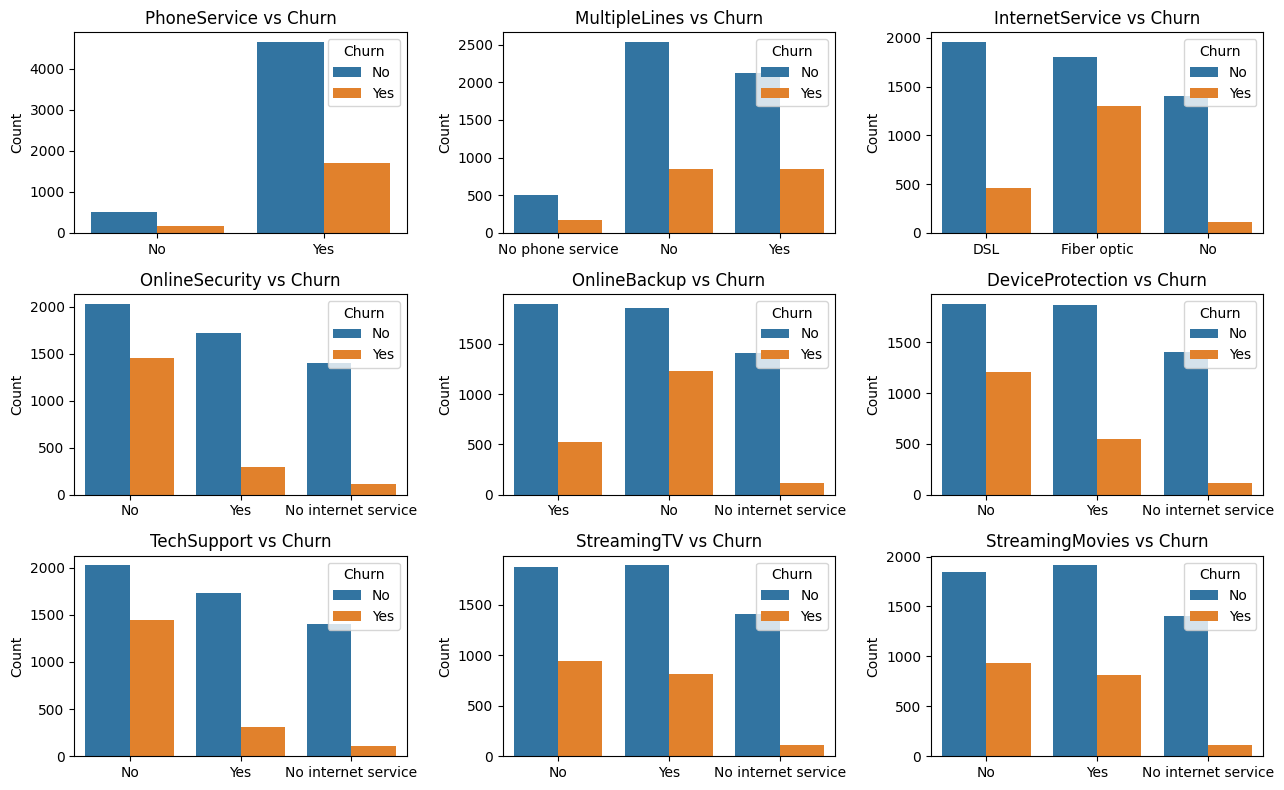

In [18]:

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
    
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Churn', loc='upper right')

plt.tight_layout()
plt.show()

#Customers with Fiber optic internet show noticeably higher churn compared to DSL and no internet users.

Users who do not have OnlineSecurity, TechSupport, or OnlineBackup have significantly higher churn rates.

Customers with PhoneServices and MultipleLines show moderate churn, but the different is not as strong as internet-related services

Overall, lack of value-added services (security, support, backup) is strongly associated with higher customer churn.

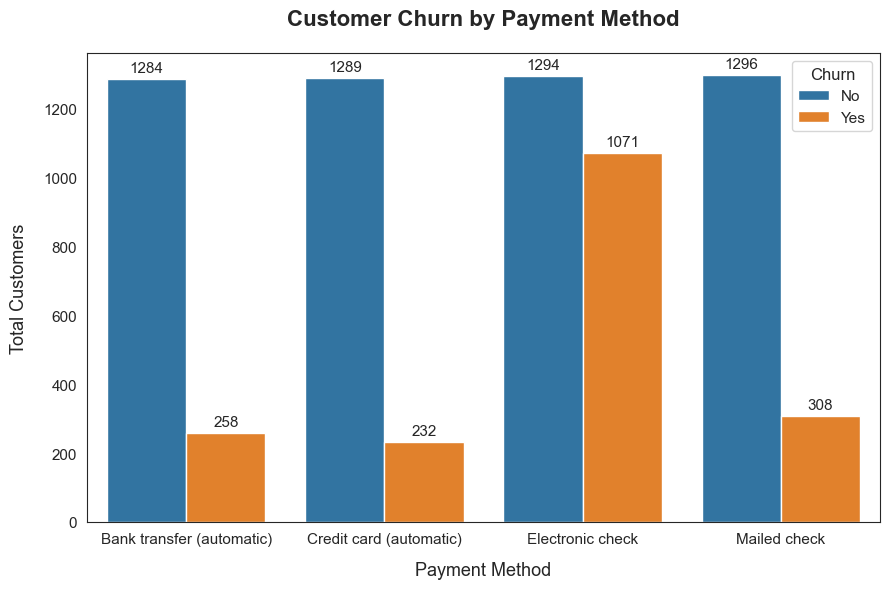

In [19]:
df_plot = df.groupby(['PaymentMethod', 'Churn']).size().reset_index(name='Count')

plt.figure(figsize=(9, 6))
sns.set_style("white")

ax = sns.barplot(data=df_plot, x='PaymentMethod', y='Count', hue='Churn', palette=['#1f77b4', '#ff7f0e'])

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11)

plt.title('Customer Churn by Payment Method', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Payment Method', fontsize=13, labelpad=11)
plt.ylabel('Total Customers', fontsize=13, labelpad=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(title='Churn', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

#Customers using electronic check as a payment method are more likely to churn.

In [20]:
churn_rate = df.groupby(['Contract'])['Churn'].value_counts(normalize=True).unstack()*100
print(churn_rate)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


In [21]:
df.groupby(['PaymentMethod'])['Churn'].value_counts(normalize=True).unstack()*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


# Final Conclusion & Recommendations

Based on the analysis, customer churn is primarily driven by contract type, tenure, service quality, and lack of additional services.

## Key Recommendations:

- Convert month-to-month customers into long-term contracts by offering discounts and incentives.

- Improve onboarding experience for new customers (first 1–2 months) to reduce early churn.

- Enhance service quality, especially for Fiber Optic users, to justify higher pricing.

- Promote value-added services such as Online Security, Tech Support, and Backup to increase customer retention.

- Encourage customers to switch from electronic check to more reliable payment methods.

- Provide special offers or support programs for senior citizens to improve retention.

## Final Insight:
Focusing on customer experience, pricing strategy, and service quality can significantly reduce churn and improve long-term customer retention.